In [3]:
using Pkg
Pkg.add("Clustering")
Pkg.add("Distances")
Pkg.add("Plots")
Pkg.add("CSV")

using CSV
using Clustering
using Distances
using Plots
using DataFrames

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\tunak\.julia\environments\v1.12\Manifest.toml`


In [6]:
SHLD = CSV.read("C:\\Users\\tunak\\OneDrive\\Masaüstü\\Sleep_health_and_lifestyle_dataset.csv", DataFrame)

Row,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
,Int64,String7,Int64,String31,Float64,Int64,Int64,Int64,String15,String7,Int64,Int64,String15
1,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
2,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
4,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
6,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
7,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
8,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None
9,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,None


In [7]:
using DataFrames


function split_bp(bp_string)
    parts = split(bp_string, "/")
    return parse(Int, parts[1]), parse(Int, parts[2])
end


transform!(SHLD, "Blood Pressure" => ByRow(x -> split_bp(x)[1]) => :BP_Systolic)
transform!(SHLD, "Blood Pressure" => ByRow(x -> split_bp(x)[2]) => :BP_Diastolic)


select!(SHLD, Not("Blood Pressure"))



using DataFrames


bmi_mapping = Dict(
    "Normal" => 1,
    "Normal Weight" => 1, 
    "Overweight" => 2,
    "Obese" => 3
)


transform!(SHLD, "BMI Category" => ByRow(x -> bmi_mapping[x]) => "BMI Category")


transform!(SHLD, "Gender" => ByRow(x -> x == "Male" ? 0 : 1) => "Gender")
transform!(SHLD, "Sleep Disorder" => ByRow(x -> x == "None" ? 0 : 1) => "Sleep Disorder")

Row,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,BP_Systolic,BP_Diastolic
,Int64,Int64,Int64,String31,Float64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,1,0,27,Software Engineer,6.1,6,42,6,2,77,4200,0,126,83
2,2,0,28,Doctor,6.2,6,60,8,1,75,10000,0,125,80
3,3,0,28,Doctor,6.2,6,60,8,1,75,10000,0,125,80
4,4,0,28,Sales Representative,5.9,4,30,8,3,85,3000,1,140,90
5,5,0,28,Sales Representative,5.9,4,30,8,3,85,3000,1,140,90
6,6,0,28,Software Engineer,5.9,4,30,8,3,85,3000,1,140,90
7,7,0,29,Teacher,6.3,6,40,7,3,82,3500,1,140,90
8,8,0,29,Doctor,7.8,7,75,6,1,70,8000,0,120,80
9,9,0,29,Doctor,7.8,7,75,6,1,70,8000,0,120,80


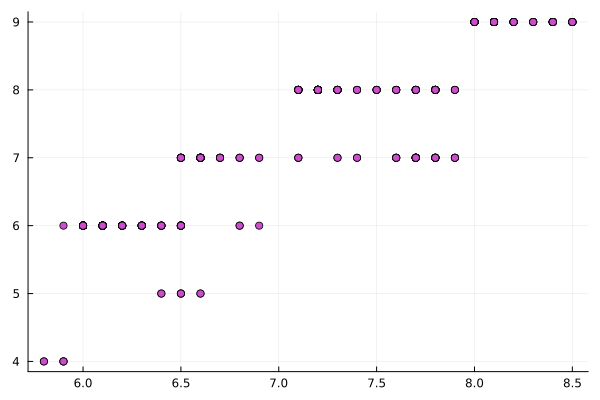

In [20]:
scatter(SHLD."Sleep Duration", SHLD."Quality of Sleep",color=:lightrainbow, legend=false)

In [12]:
selected_columns = [
    "Sleep Duration",   
    "Quality of Sleep", 
    "Stress Level", 
    "BMI Category"            
]
features = collect(Matrix(SHLD[:, selected_columns])'); 
k=3
result = kmeans(features, k, display=:iter) 

  Iters               objv        objv-change | affected 
-------------------------------------------------------------
      0       7.607700e+02
      1       5.814836e+02      -1.792864e+02 |        3
      2       4.620978e+02      -1.193858e+02 |        3
      3       4.150286e+02      -4.706917e+01 |        2
      4       3.896578e+02      -2.537080e+01 |        0
      5       3.896578e+02       0.000000e+00 |        0
K-means converged with 5 iterations (objv = 389.65780934039407)


KmeansResult{Matrix{Float64}, Float64, Int64}([7.859482758620694 6.221774193548391 7.344776119402984; 8.612068965517242 5.919354838709677 7.477611940298507; 3.3879310344827585 7.532258064516129 5.126865671641791; 1.3275862068965518 1.7258064516129032 1.2985074626865671], [2, 2, 2, 2, 2, 2, 2, 3, 3, 3  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [2.4443294745057074, 0.7525552809573242, 0.7525552809573242, 5.62981334547348, 5.62981334547348, 5.62981334547348, 1.9194907648283106, 1.2868122076185955, 1.2868122076185955, 1.2868122076185955  …  0.7728663793103578, 0.7728663793103578, 0.8109698275862343, 0.7728663793103578, 0.8109698275862343, 0.8109698275862343, 0.7728663793103578, 0.8109698275862343, 0.8109698275862343, 0.8109698275862343], [116, 124, 134], [116, 124, 134], 389.65780934039407, 5, true)

In [13]:
result.centers

4×3 Matrix{Float64}:
 7.85948  6.22177  7.34478
 8.61207  5.91935  7.47761
 3.38793  7.53226  5.12687
 1.32759  1.72581  1.29851

In [14]:
result.counts

3-element Vector{Int64}:
 116
 124
 134

In [15]:
result.assignments

374-element Vector{Int64}:
 2
 2
 2
 2
 2
 2
 2
 3
 3
 3
 2
 3
 2
 ⋮
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

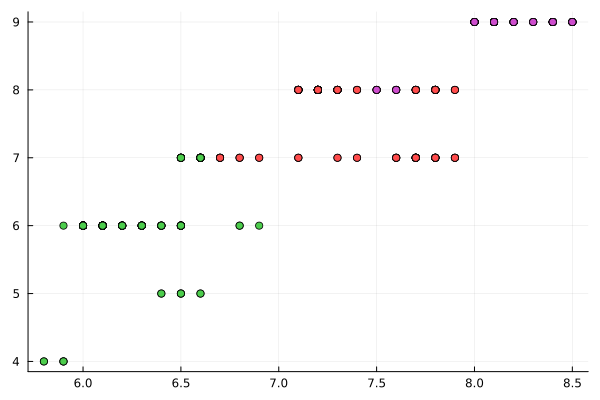

In [21]:
scatter(SHLD."Sleep Duration", SHLD."Quality of Sleep", marker_z=result.assignments, color=:lightrainbow, legend=false)

In [42]:
###1. Eksenlerin Analizi
#X Ekseni : Uyku Süresi. Sağa doğru gidildikçe kişinin günlük uyuduğu saat artıyor
#Y Ekseni : Uyku Kalitesi. Yukarı doğru çıkıldıkça kişinin uykusundan aldığı verim artıyor
###2. Kümelerin yorumu
#Sağ Üstteki Küme : Bu grup **"İdeal Uyuyanlar"**dır. Hem uyku süreleri uzun hem de kaliteleri yüksek. Algoritma bu grubu "en sağlıklı kesim" olarak bir araya toplamış.
#Sol Alttaki Küme : Bu grup **"Risk Grubu"**dur. Hem az uyuyorlar hem de uykuları kalitesiz. Muhtemelen bu kişilerin verisindeki "Stres Seviyesi" de en yüksek olanlardır.
#Orta Bölgedeki Küme: Bunlar ise **"Geçiş Grubu"**dur. Ne çok kötü ne çok iyi durumdalar.
#Algoritma, verileri 3 ana kümede toplayarak; sağlıklı uyuyanlar ile uyku problemi yaşama ihtimali olan kişileri net bir şekilde birbirinden ayırmıştır. Bu durum, uyku süresinin uyku kalitesiyle doğrudan bağlantılı olduğunu matematiksel olarak kanıtlamaktadır."

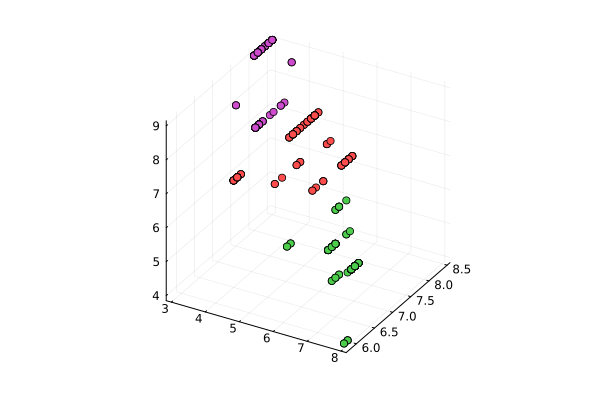

In [24]:
scatter(SHLD."Stress Level", SHLD."Sleep Duration", SHLD."Quality of Sleep", marker_z=result.assignments,
        color=:lightrainbow, legend=false)

In [ ]:
##2.Algoritmanın veriyi neden tam olarak o noktalardan böldüğünü şu şekilde açıklayabilirsin:
#Verimlilik Sınırı: Algoritma, uyku kalitesi 6'nın altında kalanları genellikle "Riskli" veya "Düşük Kaliteli" kümesine hapseder.
#Küme Ayrımı: Eğer iki küme arasında (örneğin orta grup ile üst grup arasında) belirgin bir boşluk varsa, bu durum veri setinde "7 saat uyuyanlar ile 8 saat uyuyanlar" arasında keskin bir kalite farkı olduğunu gösterir.
 

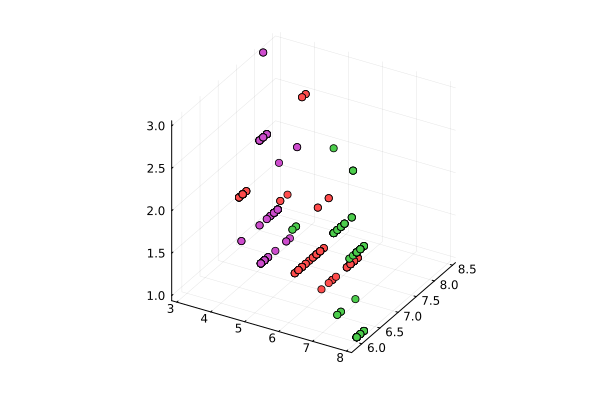

In [25]:
scatter(SHLD."Stress Level", SHLD."Sleep Duration", SHLD."BMI Category", marker_z=result.assignments,
        color=:lightrainbow, legend=false)

In [ ]:
##Grafiğe baktığımızda noktaların rastgele dağılmadığını, belli bir yöne doğru (sol alttan sağ üste) kümelendiğini görüyoruz. Uyku süresi arttıkça uyku kalitesi de artar.

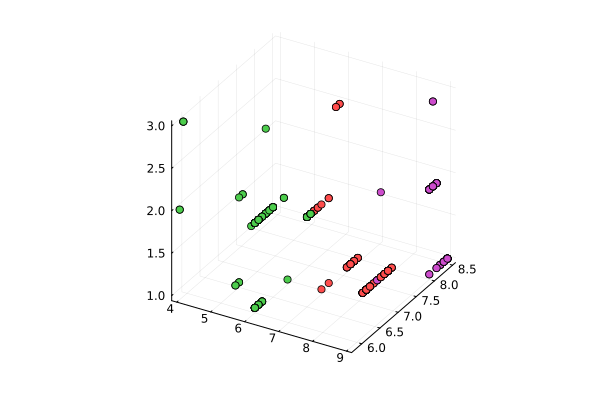

In [26]:
scatter(SHLD."Quality of Sleep", SHLD."Sleep Duration", SHLD."BMI Category", marker_z=result.assignments,
        color=:lightrainbow, legend=false)

In [43]:
##"K-Means algoritması, küme merkezlerini hayali bir ortalama nokta olarak belirlerken; K-Medoids algoritması, kümenin merkezine veri setinde gerçekten var olan bir kişiyi (noktayı) seçer.Hayali bir değer üzerinden değil, gerçek bir bireyin verileri üzerinden analiz etmiş oluyoruz.                                
##Merkez Noktalar (Medoids): Grafikte her rengin tam ortasında duran o ana noktalar, o grubun **"en tipik üyesi"**dir.                                        


In [27]:
c=Matrix(features)

4×374 Matrix{Float64}:
 6.1  6.2  6.2  5.9  5.9  5.9  6.3  7.8  …  8.0  8.1  8.1  8.0  8.1  8.1  8.1
 6.0  6.0  6.0  4.0  4.0  4.0  6.0  7.0     9.0  9.0  9.0  9.0  9.0  9.0  9.0
 6.0  8.0  8.0  8.0  8.0  8.0  7.0  6.0     3.0  3.0  3.0  3.0  3.0  3.0  3.0
 2.0  1.0  1.0  3.0  3.0  3.0  3.0  1.0     2.0  2.0  2.0  2.0  2.0  2.0  2.0

In [28]:
D=pairwise(Euclidean(),c,c,dims=2)

374×374 Matrix{Float64}:
 0.0      2.2383   2.2383   3.00666  …  4.64866  4.69042  4.69042  4.69042
 2.2383   0.0      0.0      2.84429     6.18385  6.21369  6.21369  6.21369
 2.2383   0.0      0.0      2.84429     6.18385  6.21369  6.21369  6.21369
 3.00666  2.84429  2.84429  0.0         7.44379  7.47262  7.47262  7.47262
 3.00666  2.84429  2.84429  0.0         7.44379  7.47262  7.47262  7.47262
 3.00666  2.84429  2.84429  0.0      …  7.44379  7.47262  7.47262  7.47262
 1.42829  2.2383   2.2383   2.27156     5.37494  5.4074   5.4074   5.4074
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.23607  0.1      0.1      2.83549  …  6.21369  6.245    6.245    6.245
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.23607  0.1      0.1      2.83549     6.21369  6.245    6.245    6.245
 ⋮   

In [29]:
K=kmedoids(D,4, display=:iter)

  Iters               objv        objv-change
-----------------------------------------------------
      0       3.647897e+02
      1       3.419780e+02      -2.281169e+01
      2       3.419780e+02       0.000000e+00
K-medoids converged with 2 iterations (objv = 341.9780099272271)


KmedoidsResult{Float64}([126, 21, 221, 270], [4, 4, 4, 4, 4, 4, 4, 2, 2, 2  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1.999999999999993, 1.0049875621120845, 1.0049875621120845, 2.244994432064357, 2.244994432064357, 2.244994432064357, 1.4282856857085573, 0.09999999999995453, 0.09999999999995453, 0.09999999999995453  …  1.8027756377319946, 1.8027756377319946, 1.8330302779823398, 1.8027756377319946, 1.8330302779823398, 1.8330302779823398, 1.8027756377319946, 1.8330302779823398, 1.8330302779823398, 1.8330302779823398], [176, 42, 32, 124], 341.9780099272271, 2, true)

In [30]:
K.assignments

374-element Vector{Int64}:
 4
 4
 4
 4
 4
 4
 4
 2
 2
 2
 4
 2
 4
 ⋮
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1

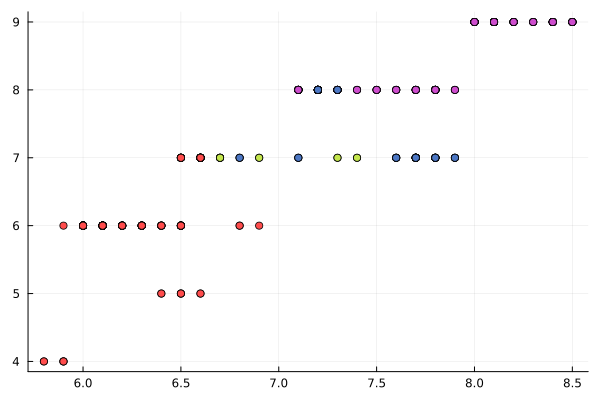

In [31]:
scatter(SHLD."Sleep Duration", SHLD."Quality of Sleep", marker_z=K.assignments,color=:lightrainbow, legend=false)

In [ ]:
##K-Medoids yöntemi kullanılarak yapılan analiz, K-Means'e kıyasla aykırı değerlerin küme merkezlerini saptırmasını engellemiştir. Bu durum, veri setindeki uyku profillerini (Düşük, Orta, Yüksek kalite) daha gerçekçi kılmıştır.
 

In [32]:
dSHLD=pairwise(Euclidean(),features, dims=2)

374×374 Matrix{Float64}:
 0.0      2.2383   2.2383   3.00666  …  4.64866  4.69042  4.69042  4.69042
 2.2383   0.0      0.0      2.84429     6.18385  6.21369  6.21369  6.21369
 2.2383   0.0      0.0      2.84429     6.18385  6.21369  6.21369  6.21369
 3.00666  2.84429  2.84429  0.0         7.44379  7.47262  7.47262  7.47262
 3.00666  2.84429  2.84429  0.0         7.44379  7.47262  7.47262  7.47262
 3.00666  2.84429  2.84429  0.0      …  7.44379  7.47262  7.47262  7.47262
 1.42829  2.2383   2.2383   2.27156     5.37494  5.4074   5.4074   5.4074
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.23607  0.1      0.1      2.83549  …  6.21369  6.245    6.245    6.245
 2.21133  2.74955  2.74955  4.53982     3.747    3.75366  3.75366  3.75366
 2.23607  0.1      0.1      2.83549     6.21369  6.245    6.245    6.245
 ⋮   

In [34]:
L=dbscan(dSHLD, 1000, 10)

DbscanResult(DbscanCluster[DbscanCluster(374, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  365, 366, 367, 368, 369, 370, 371, 372, 373, 374], Int64[])], [1], [374], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [35]:
@show length(unique(L.assignments))

length(unique(L.assignments)) = 1


1

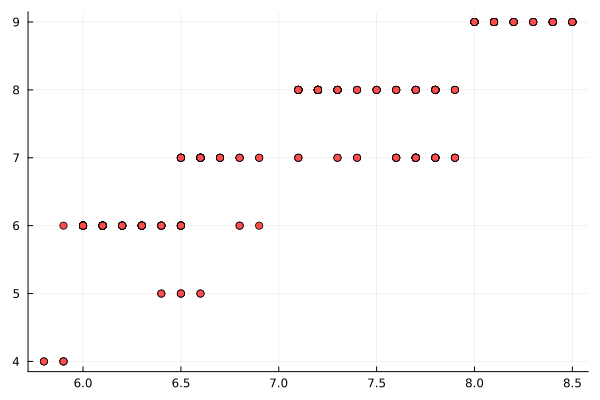

In [41]:
scatter(SHLD."Sleep Duration", SHLD."Quality of Sleep",color=:lightrainbow,  marker_z=L.assignments,legend=false)

In [44]:
##Grafikteki kümeler, toplumda benzer uyku alışkanlıklarına sahip olan kişilerin en yoğun olduğu 'merkez üslerini' göstermektedir."
#K-Means ve K-Medoids'in aksine DBSCAN, önceden bir küme sayısı (k) belirlememize gerek kalmadan verideki yoğunlukları kendisi keşfetmiştir. Bu analizde DBSCAN, uyku verisindeki gürültülü verileri (anormal uyku profillerini) başarıyla ayıklamış ve sadece istatistiksel olarak anlamlı yoğunluğa sahip olan uyku gruplarını ortaya koymuştur."

